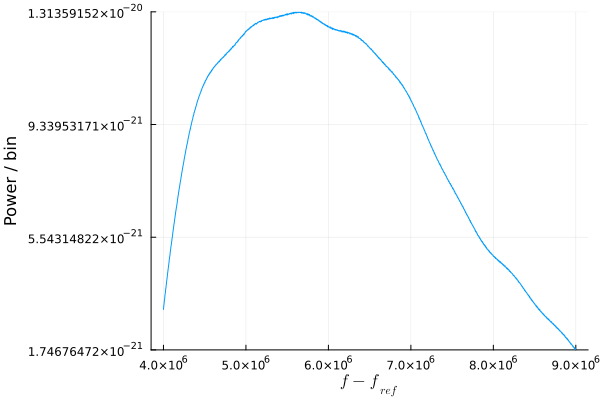

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Lenovo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Lenovo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Lenovo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Lenovo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Lenovo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Lenovo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Lenovo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194


In [345]:
using ForwardDiff
using BAT
using DataFrames

using ValueShapes, IntervalSets
using Distributions, SpecialFunctions, Random

using Plots, LaTeXStrings
using Statistics, StatsBase
using LinearAlgebra
using SavitzkyGolay
using UltraNest

"""
    All relevant fundamental constants.
"""
struct Constants
    c::Float64
    h_eV::Float64
    h_J::Float64
    qe::Float64
    eps0::Float64
    hbar_J::Float64
    hbar_eV::Float64
end

function SeedConstants()
    h_eV = 4.135667696e-15 # [eVs]
    h_J = 6.62607015e-34 # [Js]
    c = 299792458.0 # [m/s]
    qe = 1.602176634e-19 # [C]
    eps0 = 8.8541878128e-12 # [F/m]
    hbar_J = 1.054571817e-34 # [Js]
    hbar_eV = 6.582119569e-16 # [eVs]
    return Constants(c,h_eV,h_J,qe,eps0,hbar_J, hbar_eV)
end

"""
    All relevant experimental parameters.
"""
struct Experiment
    Be::Float64 # external magnetic field [T]
    A::Float64 # surface of dielectric disks [m^2]
    β::Union{Float64, Vector{Float64}} # Boost factor (assumed to be constant over this frequency range) []
    t_int::Float64 # integration time [s]
    Δω::Float64 # integration frequency interval [Hz]
    f_ref::Float64 # absolute frequency where experiment was conducted. Will be added to data[:,1] [Hz]
end

function Experiment(;Be=10.0, A=1.0, β=5.0e4, t_int=100.0, Δω=1.0e3, f_ref=11.0e9)
    return Experiment(Be, A, β, t_int, Δω, f_ref)
end

"""
    All relevant theoretical/ cosmological/ nature parameters.
"""
mutable struct Theory
    ma::Union{Float64, ForwardDiff.Dual}
    rhoa::Union{Float64, ForwardDiff.Dual}
    EoverN::Union{Float64, ForwardDiff.Dual}
    σ_v::Union{Float64, ForwardDiff.Dual} #σ_v = 218.0 # [km/s] +/- 6 according to 1209.0759
    vlab::Union{Float64, ForwardDiff.Dual}
end




#=
struct inv_sqrt_S{T <: AbstractFloat} <: Distribution{Univariate,Continuous}

    a::T
    b::T
    c::T

    # Normalized and extended to 10^-26 yr^-1  [a, b]
    # f(x) =

    μ::T
    var::T
    cov::Matrix{T}
    σ::T
end

export inv_sqrt_S


function inv_sqrt_S(a::Real, b::Real, T::DataType = Float64)

    c = 1.0 / (2.0 * (sqrt(b) - sqrt(a)))

    mean = (2.0 * c / 3.0) * (b^(3.0 / 2.0) - a^(3.0 / 2.0))
    var = (2.0 * c / 5.0) * (b^(5.0 / 2.0) - a^(5.0 / 2.0)) - mean^2


    d::inv_sqrt_S{T} = inv_sqrt_S{T}(
        a,
        b,
        c,
        mean,
        var,
        fill(var, 1, 1),
        sqrt(var)
    )
end


function Random.rand(rng::AbstractRNG, d::inv_sqrt_S{T})::T where {T <: AbstractFloat}
    res = (rand(rng) / (2.0 * d.c) + sqrt(d.a))^2
    return res
end


function Distributions.pdf(d::inv_sqrt_S{T}, x::Real)::T where {T <: AbstractFloat}
    return d.c / sqrt(x)
end

function Distributions.logpdf(d::inv_sqrt_S{T}, x::Real)::T where {T <: AbstractFloat}
    return log(d.c) - 0.5 * log(x)
end


function Distributions.cdf(d::inv_sqrt_S{T}, x::Real)::T where {T <: AbstractFloat}
    return (2.0 * d.c * (sqrt(x) - sqrt(d.a)))
end


function Distributions.minimum(d::inv_sqrt_S{T})::T where {T <: AbstractFloat}
    d.a
end

function Distributions.maximum(d::inv_sqrt_S{T})::T where {T <: AbstractFloat}
    d.b
end


function Distributions.insupport(d::inv_sqrt_S{T}, x::Real)::Bool where {T <: AbstractFloat}
    Distributions.minimum(d) <= x <= Distributions.maximum(d)
end

Base.eltype(d::inv_sqrt_S{T}) where {T <: AbstractFloat}= T

Statistics.mean(d::inv_sqrt_S) = d.μ

Statistics.var(d::inv_sqrt_S) = d.var

Statistics.cov(d::inv_sqrt_S) = d.cov
=#

"""
    Maxwell Boltzmann distribution rudimentary implementation. (May be necessary to expand.)
"""
struct MaxwellBoltzmann{T <: AbstractFloat} <: Distribution{Univariate,Continuous}
    a::Real

    μ::T
    var::T
    cov::Matrix{T}
    σ::T
end

function MaxwellBoltzmann(a::Real, T::DataType = Float64)
    mean = 2.0 * a * sqrt(2/pi)
    var = a^2.0 * (3 * pi - 8.0) / pi

    d::MaxwellBoltzmann{T} = MaxwellBoltzmann{T}(
        a,
        mean,
        var,
        fill(var, 1, 1),
        sqrt(var)
    )
end

function Distributions.pdf(d::MaxwellBoltzmann{T}, x::Real) where {T <: Real}
    return 4.0 * pi / sqrt(2.0 * pi)^3. * x^2. / d.a^3. * exp(-x^2. / (2.0*d.a^2.))
end

function Distributions.logpdf(d::MaxwellBoltzmann{T}, x::Real) where {T <: Real}
    return log(4.0 * pi / sqrt(2.0 * pi)^3. * x^2. / d.a^3.) * (-x^2.) / (2.0*d.a^2.)
end

using SpecialFunctions

function Distributions.cdf(d::MaxwellBoltzmann{T}, x::Real) where {T <: Real} # 30 μs Dont broadcast if not absolutely necessary!
    return erf(x / (sqrt(2) * d.a)) - sqrt(2 / pi) * x * exp(-x^2 / (2 * d.a^2)) / d.a
end

function Random.rand(rng::AbstractRNG, d::MaxwellBoltzmann{T}) where {T <: Real}
    x = randn(rng, Float64) * d.a 
    y = randn(rng, Float64) * d.a 
    z = randn(rng, Float64) * d.a 
    vsq = x^2.0 + y^2.0 + z^2.0
    res = sqrt(vsq)
    return res
end

using SpecialFunctions

"""
    Boosted Maxwell Boltzmann distribution rudimentary implementation. (May be necessary to expand.)
    Sun velocity has to be taken into consideration! Effectively implements formula (25) in 1701.03118. See also discussion in 1706.08388 (formula (14)).
"""
struct BoostedMaxwellBoltzmann{T <: Real} <: Distribution{Univariate,Continuous}
    σv::T
    vlab::T
end

function BoostedMaxwellBoltzmann(σv::Real, vlab::Real, T::DataType = Float64)
    d::BoostedMaxwellBoltzmann{T} = BoostedMaxwellBoltzmann{T}(
        σv,
        vlab
    )
end

function Distributions.pdf(d::BoostedMaxwellBoltzmann, x::Real)
    return 4 * pi / sqrt(2 * pi)^3 * x / (d.σv * d.vlab) * exp(-(x^2 + d.vlab^2)/(2 * d.σv^2)) * sinh(x * d.vlab / d.σv^2)
end

function Distributions.cdf(d::BoostedMaxwellBoltzmann, x::Real)
    return d.σv / (sqrt(2*pi) * d.vlab) * (exp(-(x+d.vlab)^2 /(2 * d.σv^2)) - exp((2 * x * d.vlab - x^2 -d.vlab^2) /(2 * d.σv^2))) + 1 / 2 * (erf((x-d.vlab)/(sqrt(2)*d.σv)) + erf((x+d.vlab)/(sqrt(2)*d.σv)))
end

function Random.rand(rng::AbstractRNG, d::BoostedMaxwellBoltzmann)
    x = randn(rng, Float64) * d.σv + d.vlab
    y = randn(rng, Float64) * d.σv 
    z = randn(rng, Float64) * d.σv 
    vsq = x^2 + y^2 + z^2
    res = sqrt(vsq)
    return res
end




function Theory(;ma=45.501, rhoa=0.3, EoverN=0.924, σ_v=218.0, vlab=242.1)
    return Theory(ma, rhoa, EoverN, σ_v, vlab)
end

"""
    Calculates power from a given photon count (and frequency and integration time).
    Beware: Counts do always come within a certain frequency interval. This formula implies that f is the mean
    of this interval.
"""
function Power(counts, f, Δt; c::Constants=SeedConstants())
    return f .* c.h_J .* counts ./ Δt
end

"""
    Calculates photon counts for a given power observed within a given frequency interval f_interval over time Δt.
    Be careful to choose f_interval small enough, otherwise you need an integration!
"""
function Counts(power, f_interval, Δt; c::Constants=SeedConstants())
    f = mean(f_interval)
    Δf = maximum(f_interval) - minimum(f_interval)
    return power .* Δt ./ ( f .* c.h_J ) * Δf
end

function deBroglie(mass, v=1e-3; c::Constants=SeedConstants())
    # mass::[eV]
    # v::[c]

    λdB = (c.h_eV * c.c) ./ (mass .* v)
end

"""
    Inverse of mass().
    Relativistic implementation.
"""
function freq(mass; v=0.0, c::Constants=SeedConstants())
    # mass::[eV]
    # v:: [c]
    
    # Derived from (hν)² = E² = (pc)² + (m₀c²)²
    ν = sqrt.(v.^2.0 .+ 1) .* mass ./ (c.h_eV) # [Hz]
end

"""
    Inverse of freq()
"""
function mass(freq; v=0.0, c::Constants=SeedConstants())
    # freq::[Hz]
    # v:: [c]
    m = freq .* c.h_eV ./ sqrt.(v.^2.0 .+ 1) # [eV]
end

"""
    The same as above, but solved for v. If freq < mass will return 0 instead of error!
    Freq and mass must be floats!
"""
function velocity(freq, mass; c::Constants=SeedConstants())
    # freq::[Hz]
    # mass::[eV]
    if freq >= mass / c.h_eV
        sqrt((freq / (mass / c.h_eV))^2.0 - 1.0)
    else
        0.0
    end
end

"""
    Determine prediction for central signal frequency depending on axion mass.
"""
function mu(logmass, f_ref; velo=0.0)
    # Calculate absolute frequency in Hz:
    f = freq(10.0.^logmass, v=velo)
    # Subtract reference frequency
    return f - f_ref
end

"""
    Calculate axion speed from logma and f. Same formula as used for freq() and mass().
"""
function speed(logma, f, c::Constants=SeedConstants())
    return sqrt(abs((c.h_eV * f / 10.0^logma).^2.0 .-1.0))
end


"""~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
|                                                                                           |
|                             Axion Properties                                              |
|                                                                                           |
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~"""

"""
    From 1511.02867.
    Uncertainty 5.70±0.07
"""
function ma(fa) #::[eV]
    # fa::[eV]
    return 5.70e-6 * (1e21/fa) 
end

function fa(ma)
    return 1e21 * (5.70e-6/ma)
end

αem(c::Constants=SeedConstants()) = c.qe^2 / (4*pi* c.eps0 * c.hbar_J * c.c)

function gaγγ(fa, EoverN) #::[eV^-1]
    return αem() / (2.0 * pi * fa) * abs(EoverN - 1.92)
end

function EoverN(fa, gaγγ, c::Constants=SeedConstants())
    return - 2*pi * fa * gaγγ / αem() + 1.92
end


"""~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
|                                                                                           |
|                             Signal shape, etc                                             |
|                                                                                           |
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~"""

"""
    Galactic velocity distribution in 1D.
    Formula 23 from 1701.03118v2.
    If change this to implement a different DM velocity model
"""
function velocity_distribution(v, σ_v, vlab) #::[1/c]
    # v::[c]
    # σ_v::[c]

    # Maxwell-Boltzmann distribution
    return pdf.(BoostedMaxwellBoltzmann(σ_v, vlab), v)
end

"""
    Computes dv/dω in [1/Hz].
"""
function dvdω(ω, ma; c::Constants=SeedConstants()) #::[1/Hz]
    # ω::[Hz]
    # ma::[eV]
    if ω >= ma/c.h_eV
        ω / ((ma/c.h_eV)^2. * sqrt((ω*c.h_eV/ma)^2.0 - 1.0))
    else
        0.0
    end
end

function signal_powerspectrum(ω, th::Theory, ex::Experiment; c::Constants=SeedConstants()) #::[eV^2 1/Hz]
    # ω::[Hz]   
    # σ_v::[c]
    # rhoa::[GeV/cm^3]
    # ma::[eV]
    ma = scale_ma(th.ma)
    σ_v = scale_σv(th.σ_v)
    vlab = scale_σv(th.vlab)

    v = velocity.(ω, ma) # in []

    prefactor = signal_prefactor(th, ex; c=c)
    sp =  prefactor .* velocity_distribution(v, σ_v, vlab) .* dvdω.(ω, ma) #::[1e-27 J/s 1/Hz] (if scaling = 1e27)
    return sp  
end

function signal_prefactor(th::Theory, ex::Experiment; scaling=1e27, c::Constants=SeedConstants())
    ma = scale_ma(th.ma)

    # convert rhoa from [GeV/cm^3] to [eV^4]
    rhoa = th.rhoa * 1e9 * 1e6 * c.c^3.0 * c.hbar_eV^3.0

    # convert rhoa from [GeV/cm^3] to [eV^2/m^2]
    #rhoa = rhoa * 1e9 * 1e6 * c.c * c.hbar_eV

    gag = gaγγ(fa(ma),th.EoverN) # [eV^-1]

    # convert Be from [T] to [eV^2]
    Be = ex.Be * sqrt(c.eps0 * c.c^5.0 * c.hbar_J^3.0) / c.qe^2.0 # 4 * pi * [eV^2]

    # convert A from [m^2] to [eV^-2]
    A = ex.A / (c.c^2.0 * c.hbar_eV^2.0) # [eV^-2]

    # This prefactor returns 1.712 for the values used to calculate 2.6 in Knircks Thesis. Result from Knirck: 1.6
    prefactor = rhoa/ma^2.0 * gag^2.0 * Be^2.0 * A * ex.β * (c.qe/c.hbar_eV) * scaling #::[1e-27 J/s] (if scaling = 1e27)
    return prefactor
end

"""
    Calculate number count of photons from signal (complete frequency range), assuming a fixed frequency of ma (i.e. v=0). Difference should not matter in the end, I hope!
"""
function signal_counts(th::Theory, ex::Experiment; c::Constants=SeedConstants())
    ma = scale_ma(th.ma)
    P_tot = signal_prefactor(th, ex; c=c, scaling=1.0)
    Eγ = freq(ma) * c.h_J
    Counts = P_tot / Eγ * ex.t_int
    return Counts
end

function signal_counts_bin_old(frequency, th::Theory, ex::Experiment; c::Constants=SeedConstants()) # 80 μs
    ma = scale_ma(th.ma)
    σ_v = scale_σv(th.σ_v)

    prefactor = signal_prefactor(th, ex; c=c, scaling=1.0) # 232 ns
    Eγ = freq(ma) * c.h_J # This can be assumed constant, since the width of the peak is very small compared to f_ref. Parts far away from peak are 0 anyways...
    # cdf part is integral over maxwell distribution. freq = data[1] are bin_centers
    Counts = prefactor ./ Eγ .* ex.t_int .* (cdf.(MaxwellBoltzmann(σ_v), velocity.(frequency .+ ex.Δω/2, ma)) .- cdf.(MaxwellBoltzmann(σ_v), velocity.(frequency .- ex.Δω/2, ma)))
    return Counts
end

function signal_counts_bin(frequency, th::Theory, ex::Experiment; c::Constants=SeedConstants()) # 80 μs
    ma = scale_ma(th.ma)
    σ_v = scale_σv(th.σ_v)
    vlab = scale_σv(th.vlab)

    prefactor = signal_prefactor(th, ex; c=c, scaling=1.0) # 232 ns
    Eγ = freq(ma) * c.h_J # This can be assumed constant, since the width of the peak is very small compared to f_ref. Parts far away from peak are 0 anyways...
    # cdf part is integral over maxwell distribution. freq = data[1] are bin_centers
    Counts = prefactor ./ Eγ .* ex.t_int .* (cdf.(BoostedMaxwellBoltzmann(σ_v, vlab), velocity.(frequency .+ ex.Δω/2, ma)) .- cdf.(BoostedMaxwellBoltzmann(σ_v, vlab), velocity.(frequency .- ex.Δω/2, ma)))
    return Counts
end


scale_ma(ma) = 1e-6 * ma
scale_σv(σv,c::Constants=SeedConstants()) = σv * 1e3 / c.c



function gaussian_noise(f_ini, f_fin, Δf; scale=1.0)
    f_arr = make_f(f_ini, f_fin, Δf)
    noise_pow = rand(BAT.StandardMvNormal(length(f_arr))) .* scale
    noise = hcat(f_arr, noise_pow)
    noise = DataFrame(noise, [:freq, :pow])
    insertcols!(noise, :noise => noise_pow)
    return noise
end

make_f(f_ini, f_fin, Δf) = collect(range(f_ini, f_fin, step=Δf))

"""
    Add an arbitrary 3rd order polynomial background function with two sines to any dataset.
"""
function add_artificial_background!(data)
    #bg =  (deepcopy(data[!, :freq]).-7e6).^3 .* 3e-40 .* (1. +randn()/5) .- (deepcopy(data[!, :freq]).-7e6).^2 .* 1e-34 .* (1. +randn()/5) .- (deepcopy(data[!, :freq]).-7e6) .* 3e-27 .* (1. +randn()/5) .+ 1e-20  .+ 2e-24 .* (1. +randn()) .* sin.(deepcopy(data[!, :freq])./5e4) .+ 1e-23 .* (1. +randn()) .* sin.(deepcopy(data[!, :freq])./20e4) #.* 
    bg = 1e-20 .* (erf.((data[!,:freq].-data[1,:freq])/5e5) .* (data[1,:freq] ./data[!,:freq]).^3 .+ exp.(-((data[!,:freq].-6.5e6 .* (1. +randn()/15))./2e6 ./ (1. +randn()/10)).^2)) .+ 5e-23 .* (1. +randn()) .* sin.((deepcopy(data[!, :freq]) .+ randn() * data[1, :freq])./10e4) .+ 4e-22 .* (1. +randn()) .* sin.((deepcopy(data[!, :freq]) .+ randn() * data[1, :freq])./25e4)
    #bg[rand(1:length(data[!,:freq]), 10)] .+= 3e-23
    insertcols!(data, :background => bg)
    data[!, :pow] .+= bg
    return data
end

"""
    Add an axion specified by signal to your dataset.
"""
function add_axion!(data, signal, ex)

    my_axion = let f = data[!, :freq], ex = ex
        function ax(parameters)
            sig = axion_forward_model(parameters, ex, f.+ex.f_ref)
            if maximum(sig) > 0.0
                nothing
            else
                error("The specified axion model is not within the frequency range of your data. Fiddle around with signal.ma or options.f_ref!")
            end
            return sig
        end

    end
    ax = my_axion(signal)
    if in("axion", names(data))
        @warn "Your data seem to already contain an axion. You are now throwing another one in!
        Problem is: You will only be able to save metadata for one axion. That means you're on your own now!"
        data[!, :pow] += ax
        insertcols!(data, :axion => ax, makeunique=true)
    else
        data[!, :pow] += ax
        insertcols!(data, :axion => ax)
    end
    return data
end

function Δω(data::DataFrame) 
    Δωvec = [data[i,1] - data[i-1,1] for i in 2:length(data[:,1])]
    Δωvec2 = vcat(Δωvec[2:end], Δωvec[1])
    if Δωvec ≈ Δωvec2
        nothing
    else
        @warn "The distances between datapoints in your dataset seem not to be equal. This will not change much, but you might wanna look into that!"
    end
    return mean(Δωvec)
end


function map_idx(idx::Real, idx_range::AbstractUnitRange{<:Integer})
    i = idx - minimum(idx_range)
    n = length(eachindex(idx_range))
    n_2 = n >> 1
    ifelse(i <= n_2, i, i - n)
end

function dist_k(idx::CartesianIndex, ax::NTuple{N,<:AbstractUnitRange{<:Integer}}, harmonic_distances::NTuple{N,<:Real}) where N
    mapped_idx = map(map_idx, Tuple(idx), ax)
    norm(map(*, mapped_idx, harmonic_distances))
end

function dist_array(dims::NTuple{N,<:Real}, harmonic_distances::NTuple{N,<:Real}) where N
    cart_idxs = CartesianIndices(map(Base.OneTo, dims))
    dist_k.(cart_idxs, Ref(axes(cart_idxs)), Ref(harmonic_distances))
end

function amplitude_forward_model(offset, slope, zero_mode, dist_array)
    corr = exp.(offset .+ slope .* log.(dist_array[2:end]))
    corr = vcat(zero_mode, corr)
    corr.^0.5 
end

######## HARMONIC TRANSFORM #######

function harmonic_transform(input, n_x_pad::Integer, harmonic_pad_distances::Tuple, ht)
    function apply_ht(ht, dp::Vector{Float64})
        ht * dp
    end
    function apply_ht(ht, dp::Vector{ForwardDiff.Dual{T, V, N}}) where {T,V,N}
        val_res = ht *  ForwardDiff.value.(dp)
        psize = size(ForwardDiff.partials(dp[1]), 1)
        ps = x -> ForwardDiff.partials.(dp, x)
        val_ps = map((x -> ht*ps(x)), 1:psize)
        ForwardDiff.Dual{T}.(val_res, val_ps...)
    end
    apply_ht(ht, input) * (harmonic_pad_distances[1]) #/ sqrt(n_x_pad)) #Zero mode is integrated position space!!!!1
end


######## GAUSSIAN PROCESS ######

function gp_forward_model(ξ, amplitude, harmonic_transform, nbin)
    harmonic_gp = amplitude .* ξ
    gp = harmonic_transform(harmonic_gp)
    gp[1:nbin]
end

###### GAUSSIAN SHAPE ######

function gaussian_shape_forward_model(amplitude::Real, mean::Real, std::Real, x::Vector{Float64})
    function eval_gauss(amplitude::Real, mean::Real, std::Real, x::Real)
        amplitude .* pdf(Normal(mean, std),x)
    end
    map(xx -> eval_gauss(amplitude, mean, std, xx), x)
end


"""
"""
function axion_forward_model(th::Theory, ex::Experiment, f::Vector{Float64})
    c = SeedConstants()
    #σ_v = 218.0 # [km/s] +/- 6 according to 1209.0759
    #σv *= 1.0e3/c.c

    function eval_axion(th::Theory, ex::Experiment, f::Real)
        counts = signal_counts_bin(f, th, ex)
        Power(counts, f, ex.t_int)
    end
    map(ff -> eval_axion(th, ex, ff), f)
end


export plot_data, plot_fit, plot_truths

"""
    Modifies standard BAT output to nice corner plot.
    Not yet, but hopefully soon!
"""
function corner(samples, params; modify=true, truths=nothing, savefig=nothing)

    lp = length(params)
    top_plots = [i+1+(i-1)*lp:i*lp for i in 1:lp-1]
    bottom_plots = [i*lp+1:i*(lp+1) for i in 1:lp-1]
    diag_plots = [i*(lp+1)+1:i*(lp+1)+1 for i in 0:lp-1]

    plot(
        samples, vsel=collect(params), bins=50, globalmode=true
    )
    if modify == true
        # To modify the plot, you can just overplot. Do something like the following:
        for range in top_plots
            for i in range
                plot!(framestyle=:none, showaxis=false, xlabel="", ylabel="", subplot=i)
            end
        end
        for range in bottom_plots
            for i in range[2:end]
                plot!(ylabel="", yformatter=_->"", subplot=i)
            end
        end
        for range in bottom_plots[1:end-1]
            for i in range
                plot!(xlabel="", xformatter=_->"", subplot=i)
            end
        end
        for range in diag_plots[1:end-1]
            for i in range
                plot!(xlabel="", ylabel="", xformatter=_->"", yformatter=_->"", subplot=i)
            end
        end
        for range in diag_plots[end-1:end]
            for i in range
                plot!(ylabel="", yformatter=_->"", subplot=i)
            end
        end
    else
        nothing
    end
    if truths === nothing
        nothing
    else
        length(truths) == lp || throw(DimensionMismatch("length of truths does not match number of parameters plotted"))
        j = 0
        for range in diag_plots
            j += 1
            for i in range
                vline!([truths[j]], color="blue", ls=:dot, lw=2, subplot=i)
            end
        end
    end
    ma_label = L"m_a [\mu\textrm{eV}]"
    rhoa_label = L"\rho_a [\textrm{GeV}/\textrm{cm}^3]"
    sigv_label = L"\sigma_v [c]"
    ma_range = 45.493660:16e-6:45.493676
    sigv_range = 6.5e-4:5e-5:8e-4
    plot!(xlabel=ma_label, ylabel=L"\textrm{P}(m_a)", xticks=ma_range, subplot=1)
    plot!(xlabel=ma_label, ylabel=sigv_label, xticks=ma_range, subplot=2)
    plot!(xlabel=ma_label, ylabel=rhoa_label, xticks=ma_range, subplot=3)
    plot!(xlabel=ma_label, ylabel=sigv_label, xticks=ma_range, subplot=4)
    plot!(xlabel=sigv_label, ylabel=L"\textrm{P}(\sigma_v)", xticks=sigv_range, subplot=5)
    plot!(xlabel=sigv_label, ylabel=rhoa_label, subplot=6)
    plot!(xlabel=ma_label, ylabel=rhoa_label, xticks=ma_range, subplot=7)
    plot!(xlabel=sigv_label, ylabel=rhoa_label, subplot=8)
    plot!(xlabel=rhoa_label, ylabel=L"\textrm{P}(\rho_a)", subplot=9)

    mysavefig(savefig)
    # Julia is weird with for clauses. To make everything show up, add this in the end!
    plot!()
end

function plot_fit(samples, data, ex; scaling=1.0, truths=nothing, savefig=nothing, kwargs...)
    #power_o = scaling .* Power(data[:,2], data[:,1] .+ kwargs[:f_ref], ex.t_int)
    #data_tmp = (data[1], power_o)
    plot_data(data; key=:pownoB, label="mock data", kwargs...)
    testpars = mode(samples)
    pow_p = fit_function(testpars,data[!, :freq],ex)
    #pow_p = Power.(counts_p, data[:,1] .+ kwargs.f_ref, ex.t_int)
    
    plot!(data[!, :freq], scaling .* pow_p, label="fit",legend=:bottomleft)
    if truths !== nothing
        plot!(data[!, :freq], fit_function(truths,data[!, :freq],ex); label="true signal")
    end
    xlabel!(L"f - f_{\textrm{ref}}")
    ylabel!(L"\textrm{Power}\;[10^{-23} \textrm{W}]")
    mysavefig(savefig)
    plot!()
end

function plot_truths(data, truths::Theory, ex::Experiment; savefig=nothing, kwargs...)
    plot_data(data,; key=:pownoB, label="sg_fit", kwargs...)
    plot!(data[!, :freq], fit_function(truths,data[!, :freq],ex); label="true signal")
    ylims!((minimum(data[!, :pownoB]),maximum(data[!, :pownoB]*1.2)))
    mysavefig(savefig)
    xlabel!("\$ f - f_{ref} \$")
    ylabel!("Power")
    plot!()
end

function plot_data(data; key=:pow, label="", savefig=nothing, overplot=false, kwargs...)
    if overplot == false
        plot(data[!, :freq], data[!, key]; label=label, kwargs...)
    elseif overplot == true
        plot!(data[!, :freq], data[!, key]; label=label, kwargs...)
    end
    ylims!((minimum(data[!, key]),maximum(data[!, key])))
    xlabel!("\$ f - f_{ref} \$")
    ylabel!("Power / bin")
    #xlims!((3.3e7,3.5e7))
    #ylims!((2200,2300))
    #mysavefig(savefig)
    #plot!()
end

function plot_exclusion(mass_bins, exclusion, fracs; signal=nothing)
    plot()
    plot( mass_bins, exclusion[1].+9.0, fillrange=fill(-13.0,length(exclusion)), fillalpha=0.35, label=string(fracs[1]))
    if size(exclusion)[1] > 1
        for i in 2:size(exclusion)[1]
            plot!(mass_bins, exclusion[i].+9.0, fillrange=fill(-13.0,length(exclusion)), fillalpha=0.35, label=string(fracs[i]))
        end
    end

    # E/N = 0.97 for KSVZ and 0.36 for DFSZ according to Haystac Palken et al
    plot!(mass_bins, log10.(1e9*gaγγ.(fa.(mass_bins*1e-6),8.0/3.0)), label="E/N = 8/3", linewidth=3, ls=:dash)
    if signal !== nothing
        scatter!([signal.ma], [log10.(1e9*gaγγ.(fa.(signal.ma*1e-6),signal.EoverN))], label="signal")
    end
    xlabel!(L"m_a\;[\mu \textrm{eV}]")
    ylabel!(L"\log (g_{a\gamma\gamma})\;[GeV^{-1}]")
    plot!()
    #mysavefig(savefig)
end

function plot_exclusion2(mass_bins, exclusion, exclusion2, fracs, fracs2; signal=nothing)
    plot()
    plot(mass_bins, exclusion[1].+9.0, fillrange=fill(-13.0,length(exclusion)), fillalpha=0.35, label="prior -28 "*string(fracs2[1]),c=:red, legend=:bottomright,ls=:dot)
    plot!(mass_bins, exclusion2[1].+9.0, fillrange=fill(-13.0,length(exclusion2)), fillalpha=0.0, label="prior -26 "*string(fracs2[1]),c=:red, lw=2)
    cs = [:blue,:green]
    if size(exclusion)[1] > 1
        for i in 2:size(exclusion)[1]
            plot!(mass_bins, exclusion[i].+9.0, fillrange=fill(-13.0,length(exclusion)), fillalpha=0.35, label="prior -28 "*string(fracs[i]),c=cs[i-1],ls=:dot)
            plot!(mass_bins, exclusion2[i].+9.0, fillrange=fill(-13.0,length(exclusion2)), fillalpha=0.0, label="prior -26 "*string(fracs[i]),c=cs[i-1], lw=2)
        end
    end

    # E/N = 0.97 for KSVZ and 0.36 for DFSZ according to Haystac Palken et al
    #plot!(mass_bins, log10.(1e9*gaγγ.(fa.(mass_bins*1e-6),5.0/3.0)), label="E/N = 5/3", linewidth=3, ls=:dash, c=:black)
    #if signal !== nothing
    #    scatter!([signal.ma], [log10.(1e9*gaγγ.(fa.(signal.ma*1e-6),signal.EoverN))], label="signal")
    #end
    #xlabel!(L"m_a\;[\mu \textrm{eV}]")
    #ylabel!(L"\log (g_{a\gamma\gamma})\;[GeV^{-1}]")
    plot!()
    #mysavefig(savefig)
end



function mysavefig(name; index=nothing, path="data/plots/", form=".pdf")
    if name !== nothing
        if index !== nothing
            save = path*name*string(index)*form
        else
            save = path*name*form
        end
        savefig(save)
    end
end








"""
    Compute the signal expectation. If BGfit is defined takes effect of BG fit on signal model into account.
"""
function fit_function(th::Theory, freq, ex::Experiment; BGfit=nothing)
    ff = Power.(signal_counts_bin(freq .+ ex.f_ref, th, ex), freq .+ ex.f_ref, ex.t_int)

    if BGfit === nothing || BGfit["type"] == "ID" || maximum(abs.(ff)) == 0.0
        nothing
    elseif BGfit["type"] == "SG"
        nff = savitzky_golay(ff ./ maximum(ff), BGfit["width"], BGfit["order"])
        ff .-= nff.y .* maximum(ff)
    else
        error("You used an unexpected argument for kwarg BGfit! Use dict with a 'type' parameter called 'ID' or 'SG'!")
    end
    return ff
end

function fit_function(p::NamedTuple, freq, ex::Experiment; BGfit=nothing)
    th = _prepare_th(p)
    fit_function(th, freq, ex; BGfit=BGfit)
end

function _prepare_th(p::NamedTuple{(:ma, :sig_v, :rhoa,)})
    return Theory(ma=p.ma,rhoa=p.rhoa,EoverN=0.92,σ_v=p.sig_v)
end

function _prepare_th(p::NamedTuple{(:ma, :sig_v, :gag,)})
    EoN = EoverN(fa(scale_ma(p.ma)),p.gag)
    return Theory(ma=p.ma,rhoa=0.3,EoverN=EoN,σ_v=p.sig_v)
end

function _prepare_th(p::NamedTuple{(:ma, :sig_v, :Cag,)})
    EoN = p.Cag + 1.92
    return Theory(ma=p.ma,rhoa=0.3,EoverN=EoN,σ_v=p.sig_v)
end

function _prepare_th(p::NamedTuple{(:ma, :sig_v, :log_gag,)})
    gag=10.0^p.log_gag
    EoN = EoverN(fa(scale_ma(p.ma)),gag)
    return Theory(ma=p.ma,rhoa=0.3,EoverN=EoN,σ_v=p.sig_v)
end

# Rhoa and Cag are two completely degenerate parameters. In reality only a combined prior is sensible.
# But to implement this, it is easier to adapt to the rest of the program and forcefully cut out a random value for rhoa, e.g. 0.3. It will not matter for our result in any way.
function _prepare_th(p::NamedTuple{(:ma, :sig_v, :CagxsqrtRhoa,)})
    EoN = p.CagxsqrtRhoa / sqrt(0.45) + 1.92
    return Theory(ma=p.ma,rhoa=0.45,EoverN=EoN,σ_v=p.sig_v)
end

function make_like(data, fit_function, ex, bg)
    likelihood = let freqs=collect(data[!, :freq]), observation=data[!, :pownoB], f=fit_function, ex=ex, BGfit=bg
        function logl(pars) 
            expectation = f(pars, freqs, ex, BGfit=BGfit)
            result = logpdf.(Normal.(expectation, std(observation)), observation)
            return LogDVal(sum(result))
        end
    end
    return likelihood
end


#=
using LogExpFunctions

samp_likelihood = let freqs=collect(data[!, :freq]), observation=Matrix(data[!, r"pownoB_"]), f=fit_function, ex=ex
    function logl(pars) 
        #println(pars)
        expectation = f(pars, freqs, ex) # 80 μs
        # Cant work with values below 0. Should only happen far away from likelihood maximum anyways
        #expectation[expectation .<= 0] .= eps(eltype(expectation))
        # Power.(sqrt.(Counts.(expectation, kwargs[:f_ref].+data[1:end,1], kwargs[:int_time])), kwargs[:f_ref].+data[1:end,1], kwargs[:int_time])
        result = logpdf.(Normal.(expectation, std(observation, dims=1)), observation) # 20 μs
        return LogDVal(sum(logsumexp(result, dims=2)))
    end
end
=#











data = gaussian_noise(4e6,9e6,2e3, scale=1e-23)
ex = Experiment(Be=10.0, A=1.0, β=5.0e4, t_int=100.0, Δω=Δω(data), f_ref=11.0e9)
# optional
signal = Theory(
    ma=45.513, 
    rhoa=0.3,
    EoverN=0.6,
    σ_v=218.0,
    vlab=242.1
)

# optional
add_artificial_background!(data)
add_axion!(data, signal, ex)
plot_data(data; key=:pow)


┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Lenovo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Lenovo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Lenovo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Lenovo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194


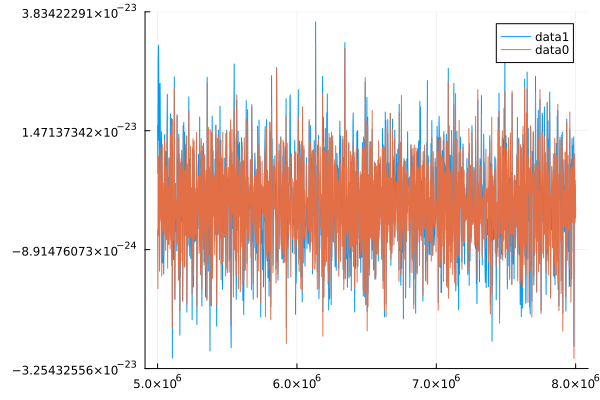

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Lenovo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Lenovo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Lenovo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194


In [370]:
"""
    Subtract (known) ideal background from data.
"""
function id_fit(data)
    data[!,:pownoB] = data[!,:pow] .- data[!,:background]
    return data
end

"""
    Makes a Savitzky Golay polynomial fit and trims the dataset by width/2 at each side if you want to.
"""
function sg_fit(data, order, width; cut=true, overwrite=false)
    b=Int(trunc(width/2))
    e=length(data[!, :freq]) - Int(trunc(width/2))

    # For stability reasons normalize data before SG fit
    sc = mean(data[!, :pow])

    sg = savitzky_golay(data[!, :pow] ./ sc, width, order)
    
    if cut == true
        data = data[b:e,:]
        ft = sg.y[b:e]
    else
        ft = sg.y
    end
    insertcols!(data, :pownoB => data[!, :pow] ./ sc - ft; makeunique=overwrite)
    data[!, :pownoB] .*= sc
    return data
end
BGfit_dict = Dict(
    "type" => "SG",
    "width" => 21,
    "order" => 4
)

data0 = sg_fit(data, BGfit_dict["order"], BGfit_dict["width"]; cut=true)
data1 = id_fit(data)

#plot(data0[!,:freq],data0[!,:noise])
# Filter data1 for frequency range 5e6 to 8e6
mask1 = (data1[!,:freq] .>= 5e6) .& (data1[!,:freq] .<= 8e6)
freq1_filtered = data1[!,:freq][mask1]
pow1_filtered = data1[!,:pownoB][mask1]

# Filter data0 for the same frequency range
mask0 = (data0[!,:freq] .>= 5e6) .& (data0[!,:freq] .<= 8e6)
freq0_filtered = data0[!,:freq][mask0]
pow0_filtered = data0[!,:pownoB][mask0]

# Plot filtered data
plot(freq1_filtered, pow1_filtered, label="data1")
plot!(freq0_filtered, pow0_filtered, label="data0")


In [311]:
length(pow0_filtered) 

1501

In [343]:
using StatsBase
spearman_corr = corspearman(pow1_filtered, pow0_filtered)

0.9815765574836482

# Spearman Correlation

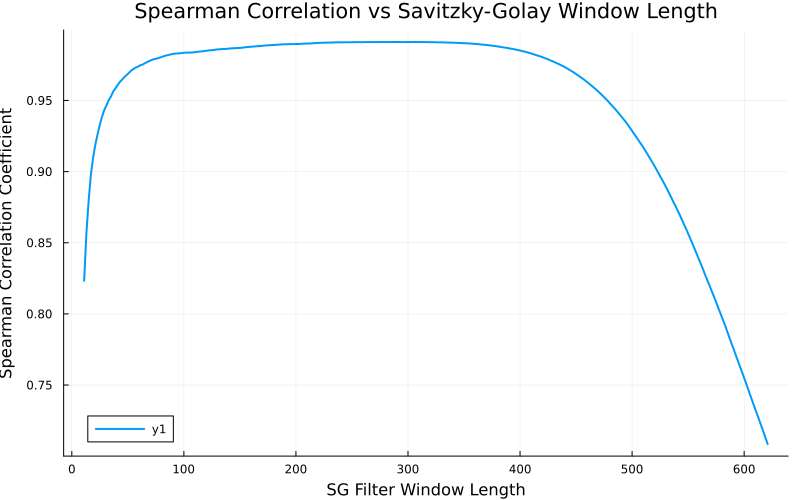

In [ ]:
using StatsBase
using Plots

# Initialize data and experiment
data = gaussian_noise(4e6, 9e6, 2e3, scale=1e-23)
ex = Experiment(Be=10.0, A=1.0, β=5.0e4, t_int=100.0, Δω=Δω(data), f_ref=11.0e9)

# Optional signal
signal = Theory(
    ma=45.513,
    rhoa=0.3,
    EoverN=0.6,
    σ_v=218.0,
    vlab=242.1
)

# Add background and signal
add_artificial_background!(data)
add_axion!(data, signal, ex)

# Function to calculate Spearman correlation for a given window length
function calculate_correlation_for_window(data_orig, window_length, order=4)
    # Make copies to avoid modifying original data
    data0 = deepcopy(data_orig)
    data1 = deepcopy(data_orig)
    
    # Apply SG filter with specified window length
    data0 = sg_fit(data0, order, window_length; cut=true)
    data1 = id_fit(data1)
    
    # Filter data1 for frequency range 5e6 to 8e6
    mask1 = (data1[!,:freq] .>= 5e6) .& (data1[!,:freq] .<= 8e6)
    pow1_filtered = data1[!,:pownoB][mask1]
    
    # Filter data0 for the same frequency range
    mask0 = (data0[!,:freq] .>= 5e6) .& (data0[!,:freq] .<= 8e6)
    pow0_filtered = data0[!,:pownoB][mask0]
    
    # Calculate Spearman correlation
    if length(pow1_filtered) > 0 && length(pow0_filtered) > 0 && length(pow1_filtered) == length(pow0_filtered)
        return corspearman(pow1_filtered, pow0_filtered)
    else
        return NaN
    end
end

# Generate odd window lengths from 21 to 621
window_lengths = 11:2:621  # This creates odd numbers: 21, 23, 25, ..., 621

# Calculate correlations for each window length
correlations = Float64[]

for window_length in window_lengths
    corr = calculate_correlation_for_window(data, window_length)
    push!(correlations, corr)
end

# Plot the results
plot(window_lengths, correlations,
    xlabel="SG Filter Window Length",
    ylabel="Spearman Correlation Coefficient",
    title="Spearman Correlation vs Savitzky-Golay Window Length",
    linewidth=2,
    grid=true,
    size=(800, 500)
)

# Run Stat

In [255]:
mean(data[!,:noise])/ 1.0e-23

-0.02027805685631337

1.0

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Lenovo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Lenovo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Lenovo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194


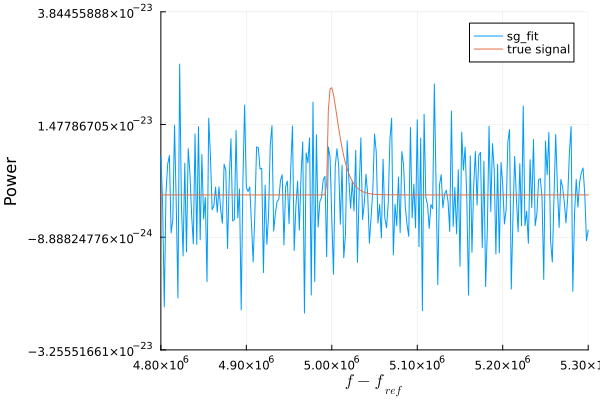

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Lenovo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Lenovo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Lenovo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\Lenovo\.julia\packages\PlotUtils\dVEMd\src\ticks.jl:194


In [372]:
plot_truths(data0, signal, ex; xrange=(4.8e6,5.3e6))
#plot!(data1[!,:freq], data1[!,:pownoB]; label="ideal fit", color=:green)


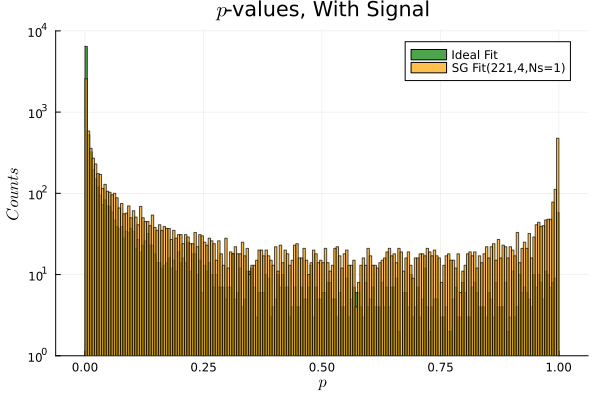

In [110]:
using Distributions
using Random
using Statistics
using PoissonRandom
using ArgCheck
using QuadGK
using RunStatistics
using RunStatistics: t_obs

#include("MADMAX-runs.ipynb")


nbins=10000
nsanity=10000
Run1=zeros(nbins)
# A=20
# w=4
# ds = Normal(0.,w)
pvs0=zeros(nsanity)
pvs1=zeros(nsanity)
epsp = 1e-7
# Squares Statistic settings
Ns1 = zeros(2); Ns1[1] = 50; Ns1[2] = Int(nbins / Ns1[1])
Ns2 = zeros(2); Ns2[1] = 50; Ns2[2] = Int(nbins / 2 / Ns2[1])
Ns5 = zeros(2); Ns5[1] = 50; Ns5[2] = Int(nbins / 5 / Ns5[1])
Ns10 = zeros(2); Ns10[1] = 50; Ns10[2] = Int(nbins / 10 / Ns10[1])


for i=1:nsanity
    data = gaussian_noise(4e6,9e6,2e3, scale=1e-23)
    ex = Experiment(Be=10.0, A=1.0, β=5.0e4, t_int=100.0, Δω=Δω(data), f_ref=11.0e9)
# optional
    signal = Theory(
    ma=45.513, 
    rhoa=0.3,
    EoverN=0.6,
    σ_v=218.0,
    vlab=242.1)

# optional
    add_artificial_background!(data)
    add_axion!(data, signal, ex)
    plot_data(data; key=:pow)
    BGfit_dict = Dict(
    "type" => "SG",
    "width" => 221,
    "order" => 4
    )

    data0 = sg_fit(data, BGfit_dict["order"], BGfit_dict["width"]; cut=true)  
    data1= id_fit(data)    
    Squares0=t_obs((data0[!,:pownoB])/ 1.0e-23,mean(data0[!,:noise])/ 1.0e-23,std(data0[!,:noise])/ 1.0e-23)
    Squares1=t_obs((data1[!,:pownoB])/ 1.0e-23,mean(data1[!,:noise])/ 1.0e-23,std(data1[!,:noise])/ 1.0e-23)
    pvs0[i] = squares_pvalue_approx(Squares0[1],Ns1, epsp)
    pvs1[i] = squares_pvalue_approx(Squares1[1],Ns1, epsp)
end
using Plots
using LaTeXStrings

p3 = histogram(pvs1, bins=200, yaxis=:log10, ylims=(1,10000), 
               color=:green, alpha=0.7, label="Ideal Fit",
               xlabel=L"$p$", ylabel=L"Counts", title=L"$p$-values, With Signal")

p3 = histogram!(pvs0, bins=200, yaxis=:log10, ylims=(1,10000), 
                color=:orange, alpha=0.7, label="SG Fit(221,4,Ns=1)",
                xlabel=L"$p$", ylabel=L"Counts", title=L"$p$-values, With Signal")


In [199]:
using Distributions
using Random
using Statistics
using PoissonRandom
using ArgCheck
using QuadGK
using RunStatistics
using RunStatistics: t_obs

#include("MADMAX-runs.ipynb")

nbins = Int((9e6-4e6)/2e3)  # Convert to integer
nsanity = 10000
Run1 = zeros(nbins)
# A=20
# w=4
# ds = Normal(0.,w)
pvs01 = zeros(nsanity)
pvs11 = zeros(nsanity)
pvs20 = zeros(nsanity)
pvs50 = zeros(nsanity)
pvs100 = zeros(nsanity)
epsp = 1e-7

# Squares Statistic settings
Ns1 = zeros(2); Ns1[1] = 50; Ns1[2] = Int(nbins / Ns1[1])
Ns2 = zeros(2); Ns2[1] = 50; Ns2[2] = Int(nbins / 2 / Ns2[1])
Ns5 = zeros(2); Ns5[1] = 50; Ns5[2] = Int(nbins / 5 / Ns5[1])
Ns10 = zeros(2); Ns10[1] = 50; Ns10[2] = Int(nbins / 10 / Ns10[1])

for i = 1:nsanity
    data = gaussian_noise(4e6, 9e6, 2e3, scale=1e-23)
    ex = Experiment(Be=10.0, A=1.0, β=5.0e4, t_int=100.0, Δω=Δω(data), f_ref=11.0e9) # optional
    signal = Theory(
        ma=45.513,
        rhoa=0.3,
        EoverN=0.6,
        σ_v=218.0,
        vlab=242.1)  # optional
    add_artificial_background!(data)
    add_axion!(data, signal, ex)
    plot_data(data; key=:pow)
    BGfit_dict = Dict(
        "type" => "SG",
        "width" => 121,
        "order" => 4
    )

    data0 = sg_fit(data, BGfit_dict["order"], BGfit_dict["width"]; cut=true)
    data1 = id_fit(data)

    Squares0 = t_obs((data0[!, :pownoB]) / 1.0e-23, mean(data0[!, :pownoB]) / 1.0e-23, std(data0[!, :pownoB]) / 1.0e-23)
    Squares1 = t_obs((data1[!, :pownoB]) / 1.0e-23, mean(data1[!, :pownoB]) / 1.0e-23, std(data1[!, :pownoB]) / 1.0e-23)
    pvs01[i] = squares_pvalue_approx(Squares0[1], Ns1, epsp)
    pvs11[i] = squares_pvalue_approx(Squares1[1], Ns1, epsp)

    step = 2
    # Use actual data length instead of calculated nbins
    actual_length = length(data0[!, :pownoB])
    nbins2 = div(actual_length, step)
    Run2 = zeros(nbins2)
    newbin = 1
    l = 1
    while l <= actual_length - step + 1
        Run2[newbin] = sum((data0[!, :pownoB][l:l+step-1])/1.0e-23)
        newbin += 1
        l += step
    end
    Squares2 = t_obs(Run2, 0.0, step)
    pvs20[i] = squares_pvalue_approx(Squares2[1], Ns2, epsp)

    step = 5
    # Use actual data length instead of calculated nbins
    actual_length = length(data0[!, :pownoB])
    nbins5 = div(actual_length , step)
    Run5 = zeros(nbins5)
    newbin = 1
    l = 1
    while l <= actual_length - step + 1
        Run5[newbin] = sum((data0[!, :pownoB][l:l+step-1])/1.0e-23)
        newbin += 1
        l += step
    end
    Squares5 = t_obs(Run5, 0.0, step)
    pvs50[i] = squares_pvalue_approx(Squares5[1], Ns5, epsp)


    step = 10
    # Use actual data length instead of calculated nbins
    actual_length = length(data0[!, :pownoB])
    nbins10 = div(actual_length ,step)
    Run10 = zeros(nbins10)
    newbin = 1
    l = 1
    while l <= actual_length - step + 1
        Run10[newbin] = sum((data0[!, :pownoB][l:l+step-1])/1.0e-23)
        newbin += 1
        l += step
    end
    Squares10 = t_obs(Run10, 0.0, step)
    pvs100[i] = squares_pvalue_approx(Squares10[1], Ns10, epsp)    

end

using Plots
using LaTeXStrings



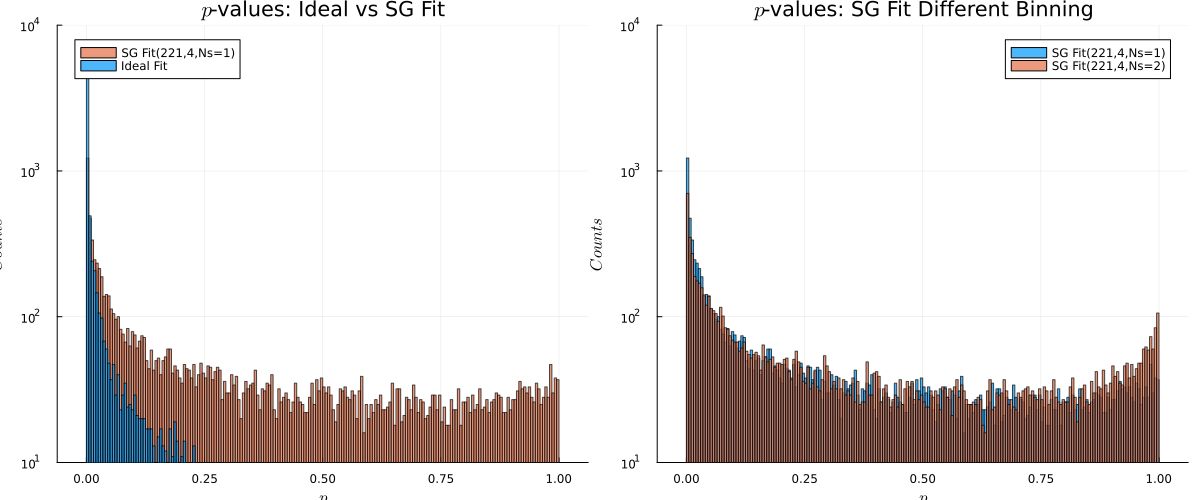

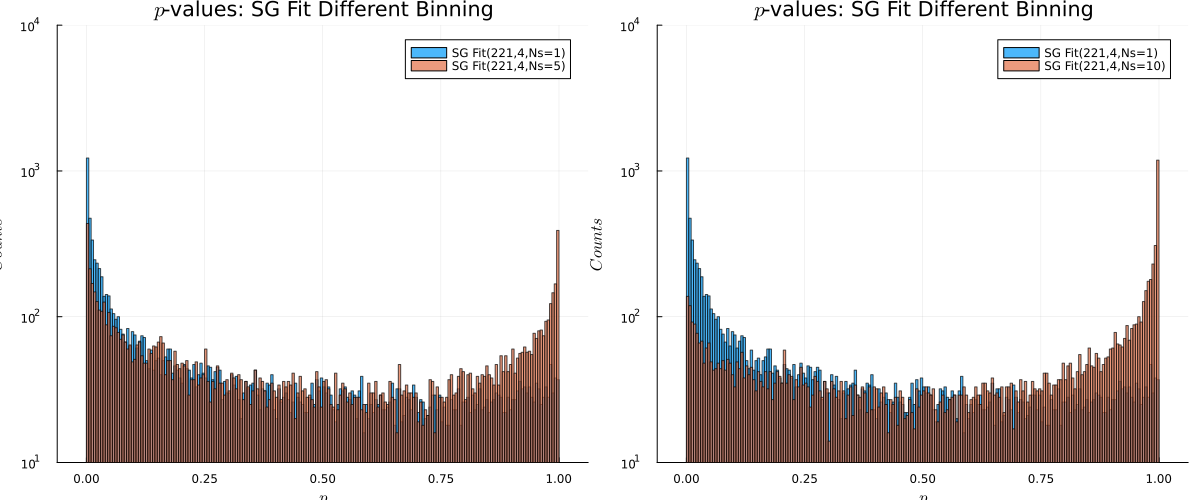

In [251]:

# First plot: pvs01 vs pvs11
p1 = histogram(pvs01, bins=400, yaxis=:log10, ylims=(10, 10000),
    color=2, alpha=0.7, label="SG Fit(221,4,Ns=1)",  # Blue
    xlabel=L"$p$", ylabel=L"Counts", title=L"$p$-values: Ideal vs SG Fit")

p1 = histogram!(pvs11, bins=400, yaxis=:log10, ylims=(10, 10000),
    color=1, alpha=0.7, label="Ideal Fit",  # Orange
    xlabel=L"$p$", ylabel=L"Counts")

# Second plot: pvs01 vs pvs20
p2 = histogram(pvs01, bins=400, yaxis=:log10, ylims=(10, 10000),
    color=1, alpha=0.7, label="SG Fit(221,4,Ns=1)",  # Blue
    xlabel=L"$p$", ylabel=L"Counts", title=L"$p$-values: SG Fit Different Binning")

p2 = histogram!(pvs20, bins=400, yaxis=:log10, ylims=(10, 10000),
    color=2, alpha=0.7, label="SG Fit(221,4,Ns=2)",  # Green
    xlabel=L"$p$", ylabel=L"Counts")
# Second plot: pvs01 vs pvs20
p3 = histogram(pvs01, bins=400, yaxis=:log10, ylims=(10, 10000),
    color=1, alpha=0.7, label="SG Fit(221,4,Ns=1)",  # Blue
    xlabel=L"$p$", ylabel=L"Counts", title=L"$p$-values: SG Fit Different Binning")

p3 = histogram!(pvs50, bins=400, yaxis=:log10, ylims=(10, 10000),
    color=2, alpha=0.7, label="SG Fit(221,4,Ns=5)",  # Green
    xlabel=L"$p$", ylabel=L"Counts")

# Second plot: pvs01 vs pvs20
p4 = histogram(pvs01, bins=400, yaxis=:log10, ylims=(10, 10000), 
    color=1, alpha=0.7, label="SG Fit(221,4,Ns=1)",  # Blue
    xlabel=L"$p$", ylabel=L"Counts", title=L"$p$-values: SG Fit Different Binning")

p4 = histogram!(pvs100, bins=400, yaxis=:log10, ylims=(10, 10000), 
    color=2, alpha=0.7, label="SG Fit(221,4,Ns=10)",  # Green
    xlabel=L"$p$", ylabel=L"Counts")    
# Combine plots side by side
combined_plot = plot(p1, p2, layout=(1, 2), size=(1200, 500))
display(combined_plot)
combined_plot = plot(p3, p4, layout=(1, 2), size=(1200, 500))

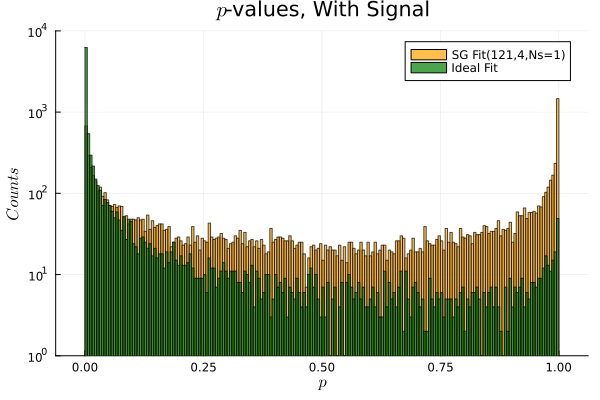

In [105]:

p3 = histogram(pvs0, bins=200, yaxis=:log10, ylims=(1,10000), 
                color=:orange, alpha=0.7, label="SG Fit(121,4,Ns=1)",
                xlabel=L"$p$", ylabel=L"Counts", title=L"$p$-values, With Signal")
p3 = histogram!(pvs1, bins=200, yaxis=:log10, ylims=(1,10000), 
               color=:green, alpha=0.7, label="Ideal Fit",
               xlabel=L"$p$", ylabel=L"Counts", title=L"$p$-values, With Signal")                

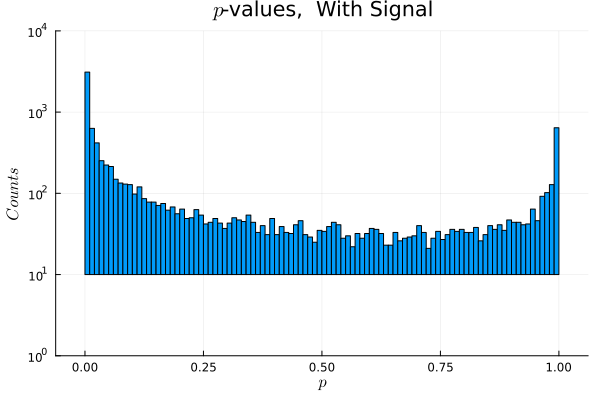

In [34]:
p3=histogram(pvs,bins=100,yaxis=:log10,ylims=(1,10000),legend=:none,xlabel=L"$p$", ylabel=L"Counts",title=L"$p$-values,  With Signal")
#p3=histogram!([pv],bins=100,color="red",xlabel=L"$p$", ylabel=L"Counts",lw=5)

